## FiftyOne Brain

### visualize embeddings

In [18]:
import fiftyone as fo
import fiftyone.zoo as foz
import fiftyone.brain as fob
from fiftyone import ViewField as F

In [2]:
dataset = foz.load_zoo_dataset("quickstart")
print(dataset)

Name:        quickstart
Media type:  image
Num samples: 200
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    uniqueness:       fiftyone.core.fields.FloatField
    predictions:      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)


In [4]:
model = foz.load_zoo_model("clip-vit-base32-torch")

results = fob.compute_visualization(
    dataset,
    model=model,
    brain_key="img_viz_test1",
    method="pca"
)

 100% |██████|    2.6Gb/2.6Gb [18.3s elapsed, 0s remaining, 129.6Mb/s]      
 100% |█████|   10.4Mb/10.4Mb [88.3ms elapsed, 0s remaining, 117.3Mb/s]    
Computing embeddings...
 100% |█████████████████| 200/200 [5.9s elapsed, 0s remaining, 36.2 samples/s]       
Generating visualization...


Connected to FiftyOne on port 5151 at localhost.
If you are not connecting to a remote session, you may need to start a new session and specify a port



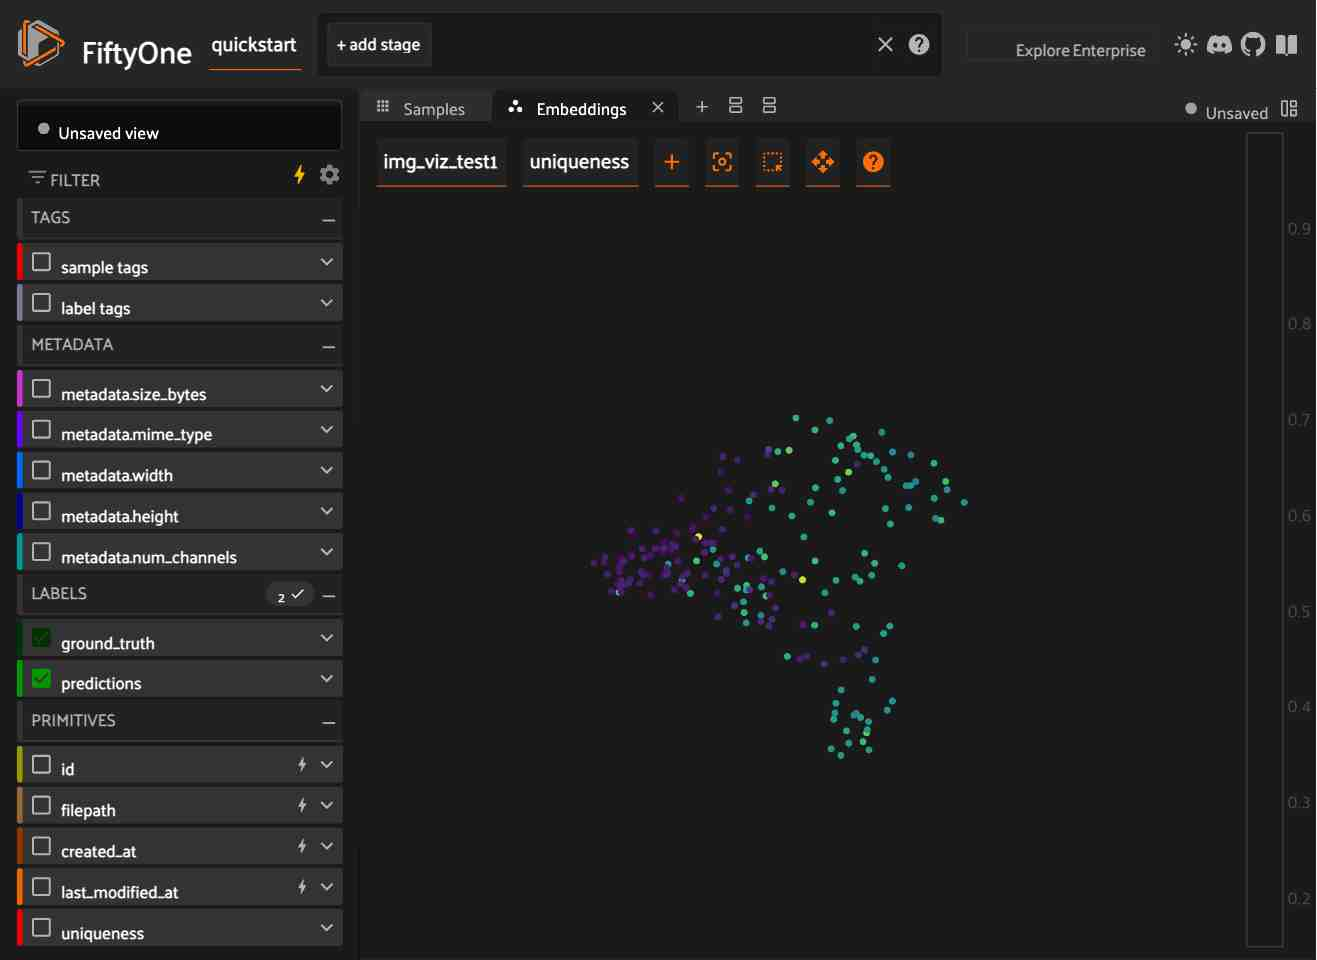

In [5]:
session = fo.launch_app(dataset)

### similarity

In [2]:
import fiftyone as fo
import fiftyone.zoo as foz
import fiftyone.brain as fob
from fiftyone import ViewField as F

In [10]:
fo.delete_dataset("quickstart")
fo.list_datasets()

['2025.06.19.17.22.46',
 '2025.06.19.17.57.43',
 'CLIP-Comparison',
 'birds-test-dataset',
 'birds-train-data',
 'clustering-demo',
 'coco-2017-test',
 'coco-2017-train',
 'demo0424',
 'evaluate-detections-tutorial',
 'kitti-train-10',
 'kolp_dataset',
 'ls-annotation-example',
 'migration_test',
 'mnist-test',
 'open-images-v6',
 'quickstart-geo',
 'quickstart-video',
 'test_raw_imgs']

In [11]:
dataset = foz.load_zoo_dataset("quickstart")
model = foz.load_zoo_model("clip-vit-base32-torch")

results = fob.compute_similarity(
    dataset,
    model=model,
    brain_key="img_sim_test1",
)

Dataset already downloaded
Loading 'quickstart'
 100% |█████████████████| 200/200 [1.4s elapsed, 0s remaining, 140.4 samples/s]         
Dataset 'quickstart' created
Computing embeddings...
 100% |█████████████████| 200/200 [6.4s elapsed, 0s remaining, 31.8 samples/s]       



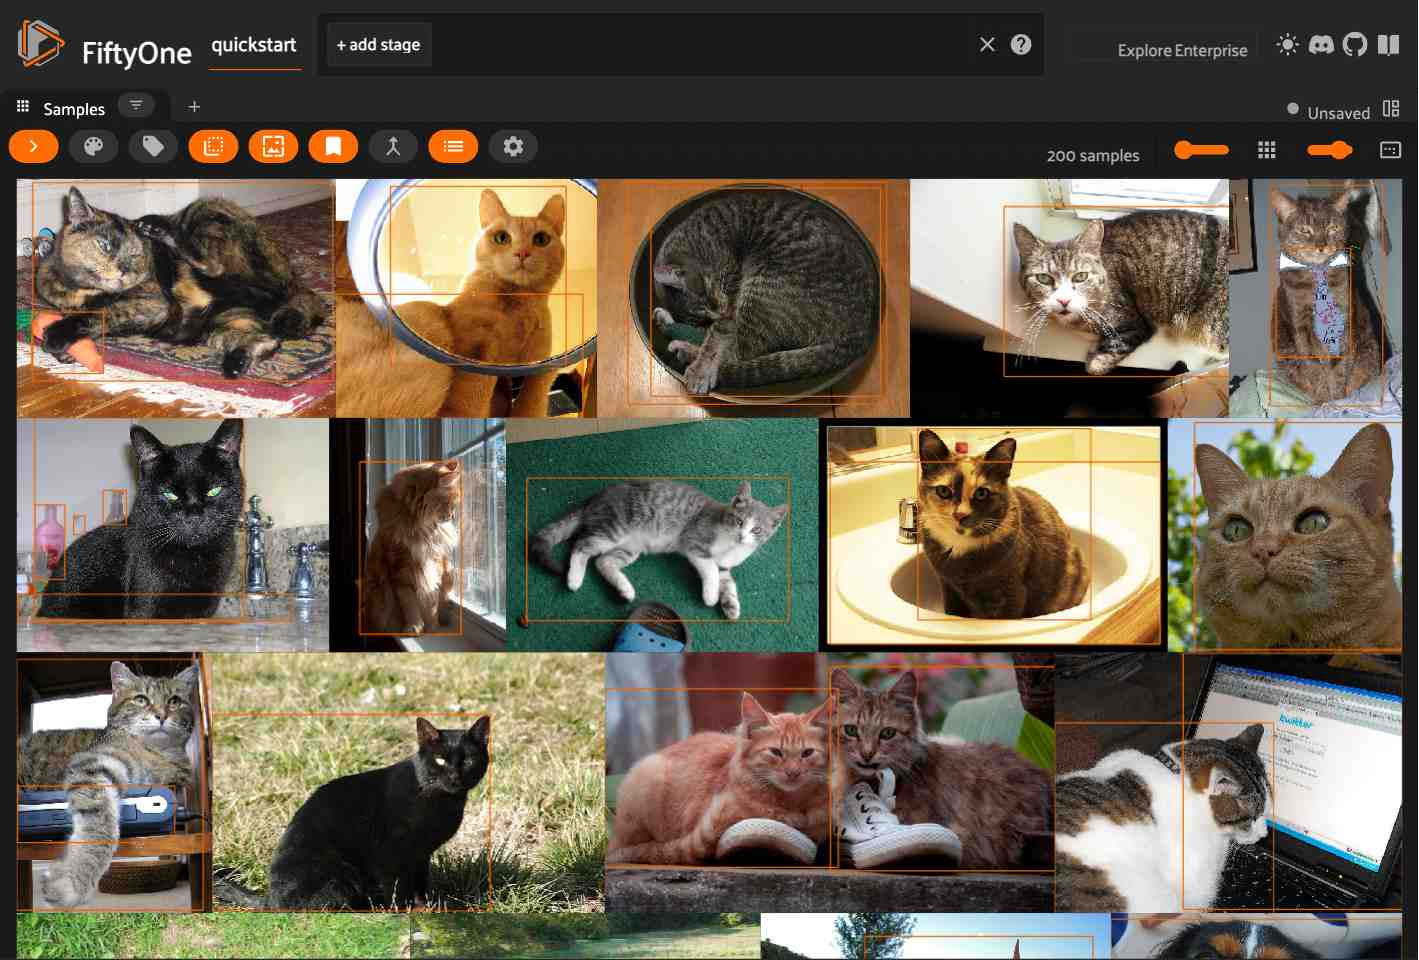


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 seconds


Could not connect session, trying again in 10 s

: 

In [12]:
session = fo.launch_app(dataset)

In [23]:
session.close()

### leaky splits

In [24]:
fo.list_datasets()

['demo0424',
 'evaluate-detections-tutorial',
 'kolp_dataset',
 'ls-annotation-example',
 'migration_test',
 'quickstart',
 'test_raw_imgs']

In [25]:
import fiftyone.utils.random as four

# Load some COCO data
dataset = foz.load_zoo_dataset("coco-2017", split="test")

# Set up splits via tags
dataset.untag_samples(dataset.distinct("tags"))
four.random_split(dataset, {"train": 0.7, "test": 0.3})

Found test info at '/Users/bhc/fiftyone/coco-2017/raw/image_info_test2017.json'
Images already downloaded
Existing download of split 'test' is sufficient
Loading 'coco-2017' split 'test'
 100% |█████████████| 40670/40670 [5.8s elapsed, 0s remaining, 7.1K samples/s]      
Dataset 'coco-2017-test' created


In [26]:
model = foz.load_zoo_model("clip-vit-base32-torch")
embeddings = dataset.compute_embeddings(model)

 100% |█████████████| 40670/40670 [18.8m elapsed, 0s remaining, 35.6 samples/s]      


In [21]:
# Find leaks
index = fob.compute_leaky_splits(dataset, embeddings=embeddings, splits=["train", "test"])
leaks = index.leaks_view()

Computing duplicate samples...
Generating neighbors graph for 40670 embeddings...
Index complete
Generating neighbors graph for 34122 embeddings...
Index complete
Duplicates computation complete



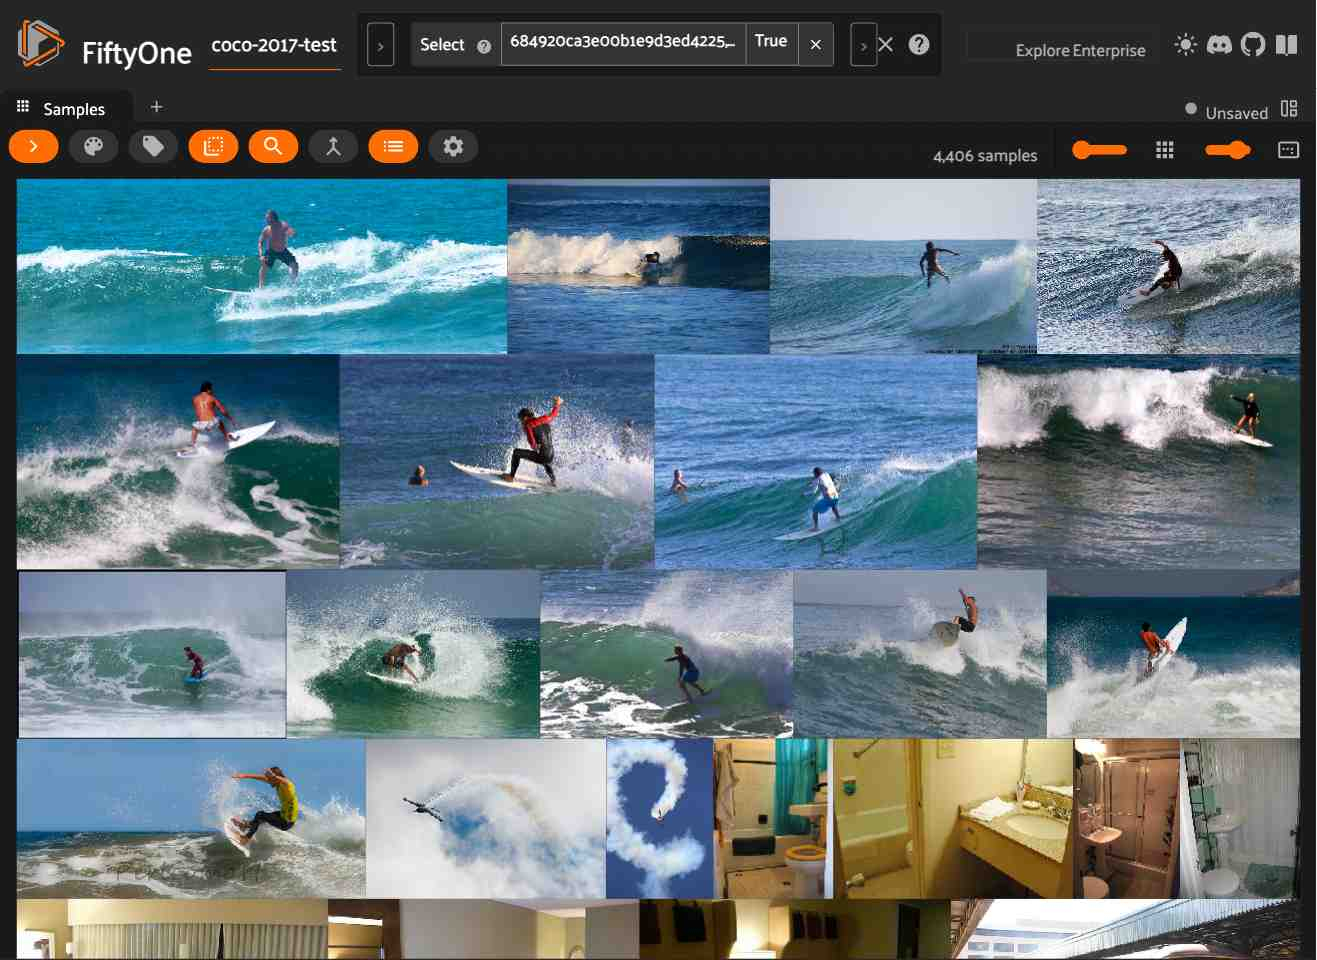

In [22]:
session = fo.launch_app(leaks)


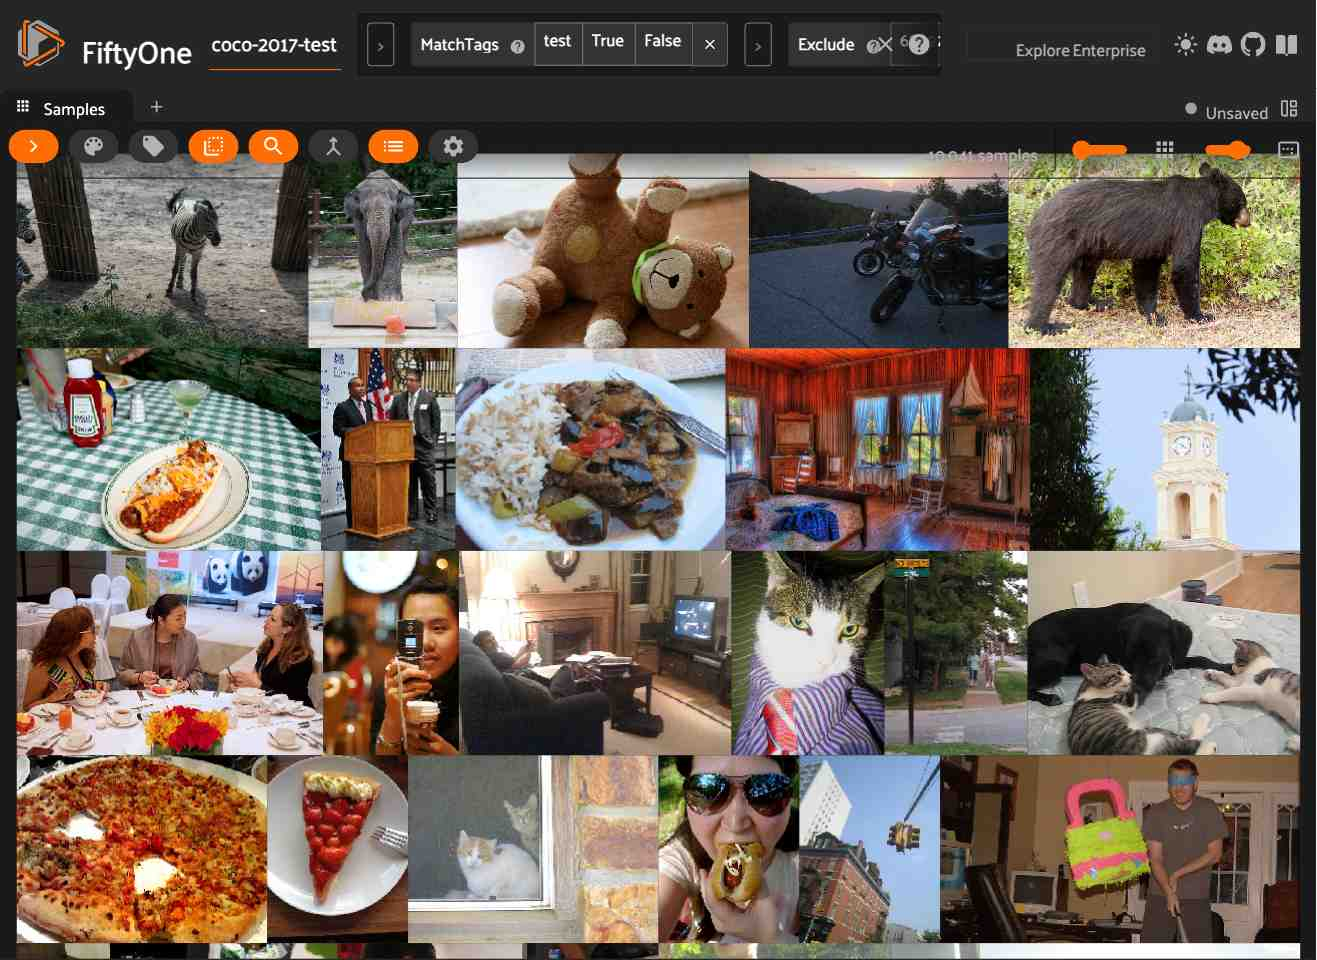

In [23]:
# The original test split
test_set = index.split_views["test"]

# The test set with leaks removed
test_set_no_leaks = index.no_leaks_view(test_set)

session.view = test_set_no_leaks

In [26]:
session.close()

### near duplicates

Computing duplicate samples...
Generating neighbors graph for 40670 embeddings...
Index complete
Generating neighbors graph for 34122 embeddings...
Index complete
Duplicates computation complete



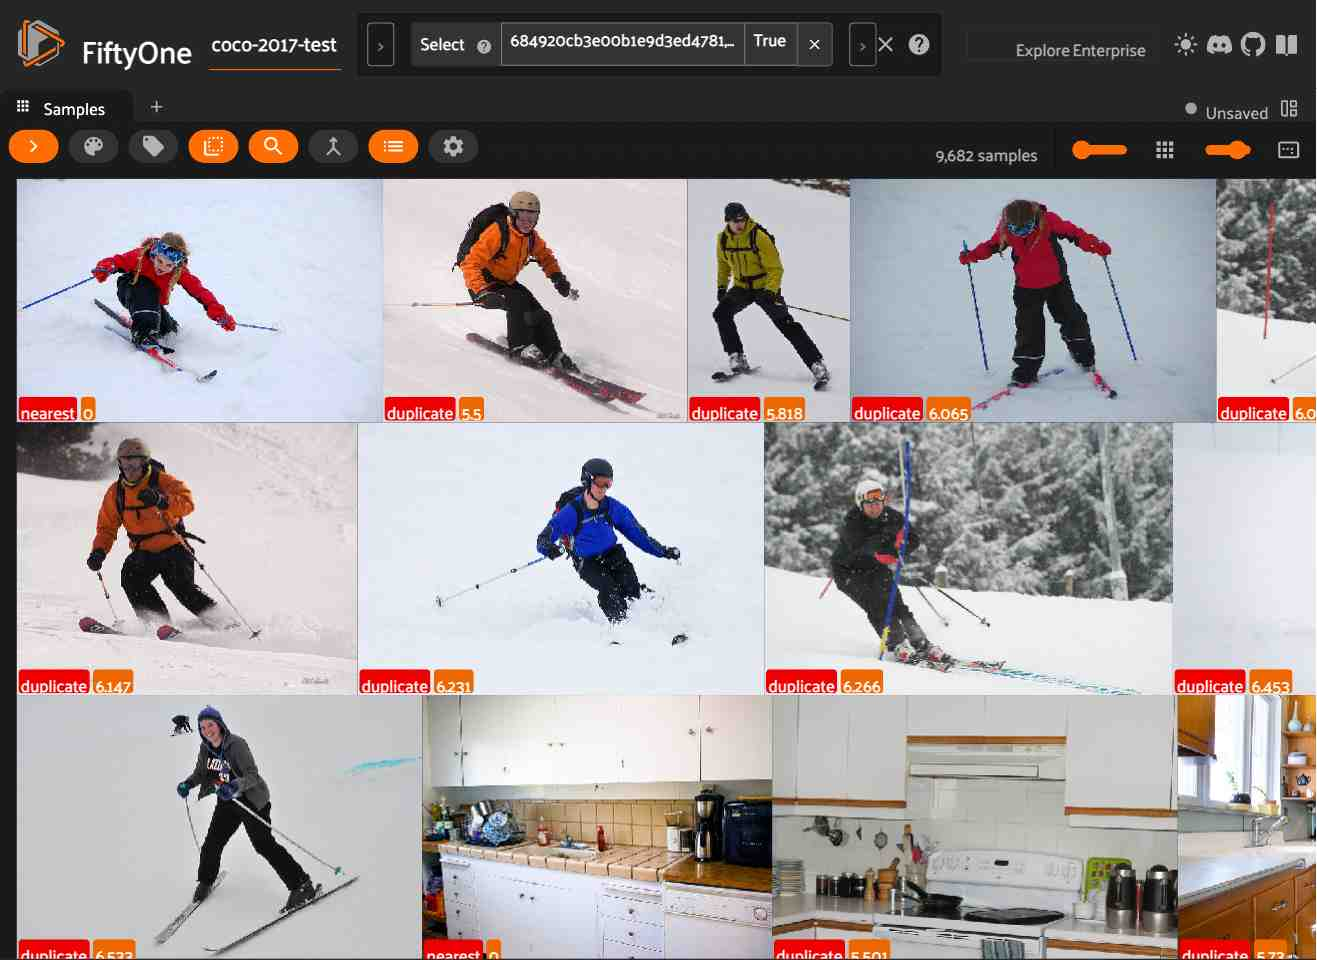

In [6]:
index = fob.compute_near_duplicates(dataset, embeddings=embeddings)

dups_view = index.duplicates_view(
    type_field="dup_type",
    id_field="dup_id",
    dist_field="dup_dist",
)
session = fo.launch_app(dups_view)

In [7]:
index.find_unique(500)
print(index.unique_ids[:5])

Computing unique samples...
Generating neighbors graph for 40670 embeddings...
Index complete
threshold: 1.000000, kept: 9, target: 500
threshold: 0.500000, kept: 7250, target: 500
threshold: 0.750000, kept: 263, target: 500
threshold: 0.625000, kept: 1688, target: 500
threshold: 0.687500, kept: 676, target: 500
threshold: 0.718750, kept: 432, target: 500
threshold: 0.703125, kept: 551, target: 500
threshold: 0.710938, kept: 491, target: 500
threshold: 0.707031, kept: 521, target: 500
threshold: 0.708984, kept: 505, target: 500
threshold: 0.709961, kept: 496, target: 500
threshold: 0.709473, kept: 499, target: 500
threshold: 0.709229, kept: 503, target: 500
threshold: 0.709351, kept: 502, target: 500
threshold: 0.709412, kept: 500, target: 500
Uniqueness computation complete
['684920ca3e00b1e9d3ed41b1', '684920ca3e00b1e9d3ed41b2', '684920ca3e00b1e9d3ed41b3', '684920ca3e00b1e9d3ed41b4', '684920ca3e00b1e9d3ed41b5']


In [8]:
%matplotlib inline

viz_results = fob.compute_visualization(dataset, embeddings=embeddings)

# Visualize the unique samples in embeddings space
plot = index.visualize_unique(viz_results)
plot.show(height=800, yaxis_scaleanchor="x")

Generating visualization...
UMAP( verbose=True)
Wed Jun 11 18:16:52 2025 Construct fuzzy simplicial set
Wed Jun 11 18:16:52 2025 Finding Nearest Neighbors
Wed Jun 11 18:16:52 2025 Building RP forest with 15 trees


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Wed Jun 11 18:16:54 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	Stopping threshold met -- exiting after 5 iterations
Wed Jun 11 18:16:59 2025 Finished Nearest Neighbor Search
Wed Jun 11 18:17:00 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed Jun 11 18:17:06 2025 Finished embedding


FigureWidget({
    'data': [{'customdata': array(['684920ca3e00b1e9d3ed41bb', '684920ca3e00b1e9d3ed41c0',
                                   '684920ca3e00b1e9d3ed41c5', ..., '684920d03e00b1e9d3ede08c',
                                   '684920d03e00b1e9d3ede08d', '684920d03e00b1e9d3ede08e'], dtype=object),
              'hovertemplate': ('<b>label: %{text}</b><br>x, y ' ... ': %{customdata}<extra></extra>'),
              'line': {'color': '#3366CC'},
              'mode': 'markers',
              'name': 'other',
              'showlegend': True,
              'text': array(['other', 'other', 'other', ..., 'other', 'other', 'other'], dtype='<U5'),
              'type': 'scattergl',
              'uid': '257460ab-8840-4154-aef6-f2078c6e2824',
              'x': array([-0.74260294,  0.5044595 ,  3.2097132 , ..., -2.7931125 ,  8.090958  ,
                           1.3719367 ], dtype=float32),
              'y': array([-2.8140497 , -0.86060536, 15.80785   , ..., 13.676642  ,  2.411489  

### exact duplicates

In [10]:
duplicates_map = fob.compute_exact_duplicates(dataset)
print(duplicates_map)

Computing filehashes...
 100% |█████████████| 40670/40670 [12.2s elapsed, 0s remaining, 3.5K samples/s]      
{}


### uniqueness

In [17]:
uniqueness = fob.compute_uniqueness(dataset, embeddings=embeddings)
print(dataset.first())

Computing uniqueness...
Generating neighbors graph for 40670 embeddings...
Index complete
Uniqueness computation complete
<Sample: {
    'id': '684920ca3e00b1e9d3ed41b1',
    'media_type': 'image',
    'filepath': '/Users/bhc/fiftyone/coco-2017/test/data/000000000001.jpg',
    'tags': ['train'],
    'metadata': <ImageMetadata: {
        'size_bytes': None,
        'mime_type': None,
        'width': 640,
        'height': 480,
        'num_channels': None,
    }>,
    'created_at': datetime.datetime(2025, 6, 11, 6, 23, 6, 883000),
    'last_modified_at': datetime.datetime(2025, 6, 12, 2, 31, 30, 929000),
    'ground_truth': None,
    'dup_type': None,
    'dup_id': None,
    'dup_dist': None,
    'uniqueness': 0.8329420665871738,
}>



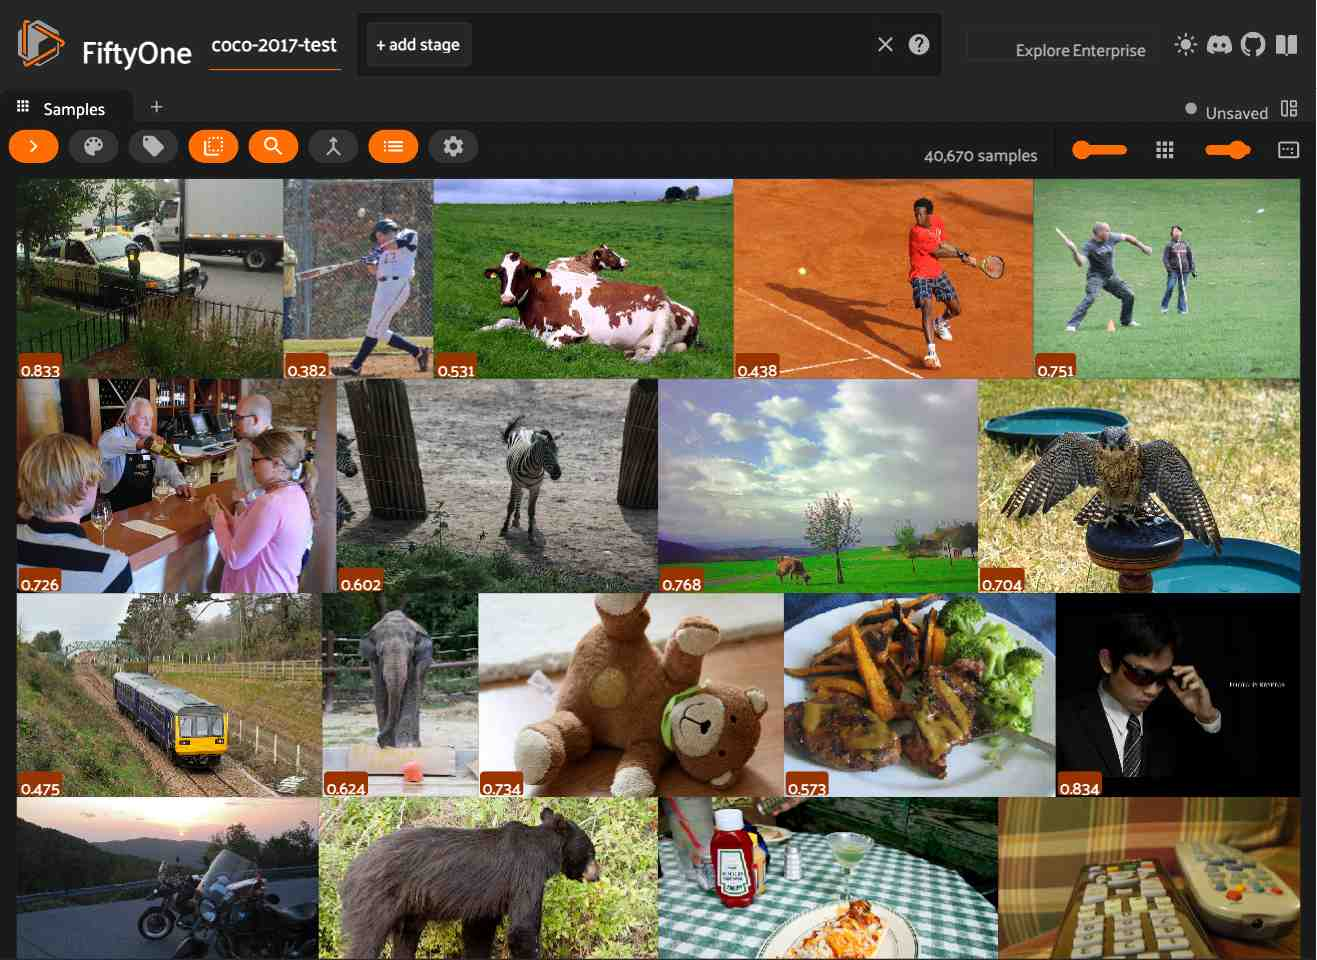

In [18]:
session = fo.launch_app(dataset)

In [19]:
session.close()

### mistakenness

In [22]:
dataset = foz.load_zoo_dataset("quickstart")
fob.compute_mistakenness(
    dataset,
    "predictions",
    label_field="ground_truth",
)
mistake_view = dataset.sort_by("mistakenness", reverse=True)
print(mistake_view)

Dataset already downloaded
Loading existing dataset 'quickstart'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use
Evaluating detections...
 100% |█████████████████| 200/200 [8.4s elapsed, 0s remaining, 18.2 samples/s]      
Computing mistakenness...
 100% |█████████████████| 200/200 [1.4s elapsed, 0s remaining, 125.2 samples/s]         
Mistakenness computation complete
Dataset:     quickstart
Media type:  image
Num samples: 200
Sample fields:
    id:                fiftyone.core.fields.ObjectIdField
    filepath:          fiftyone.core.fields.StringField
    tags:              fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:          fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:        fiftyone.core.fields.DateTimeField
    last_modified_at:  fiftyone.core.fields.DateTimeField
    ground_truth:      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.

In [23]:
print(mistake_view.first().ground_truth.detections[0])

<Detection: {
    'id': '5f452487ef00e6374aad2744',
    'attributes': {},
    'tags': [],
    'label': 'tv',
    'bounding_box': [
        0.002746666666666667,
        0.36082,
        0.24466666666666667,
        0.3732,
    ],
    'mask': None,
    'mask_path': None,
    'confidence': None,
    'index': None,
    'area': 16273.3536,
    'iscrowd': 0.0,
    'mistakenness': 0.005771428346633911,
    'mistakenness_loc': 0.16955941131917984,
}>



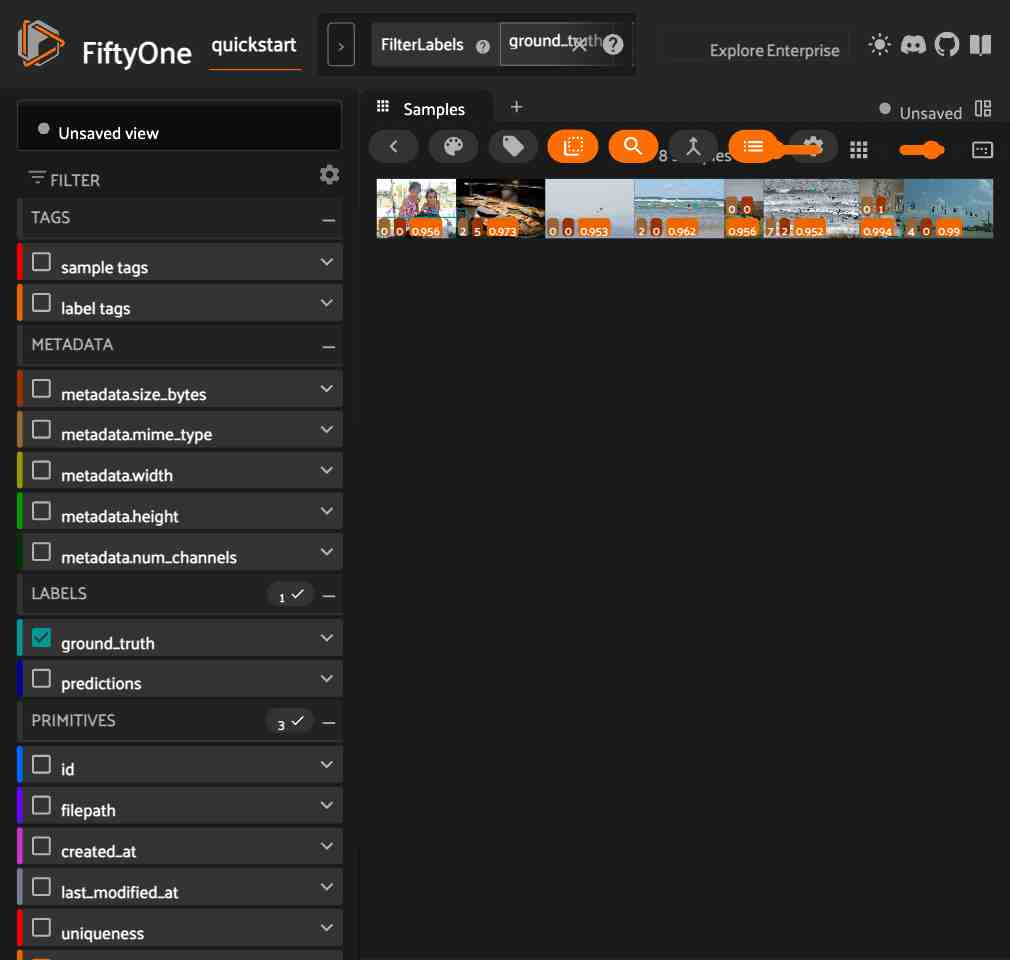

In [31]:
session.view = dataset.filter_labels("ground_truth", F("mistakenness") > 0.95)

### hardness

In [43]:
dataset = foz.load_zoo_dataset("cifar10", split="test")

Split 'test' already downloaded
Loading existing dataset 'cifar10-test'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


In [36]:
# Download the software
!git clone --depth 1 --branch v2.1 https://github.com/huyvnphan/PyTorch_CIFAR10.git

# Download the pretrained model (90MB)
!eta gdrive download --public \
    1dGfpeFK_QG0kV-U6QDHMX2EOGXPqaNzu \
    PyTorch_CIFAR10/cifar10_models/state_dicts/resnet50.pt

Cloning into 'PyTorch_CIFAR10'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 82 (delta 13), reused 60 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 5.16 MiB | 4.37 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Note: switching to '2a2e76a56f943b70403796387d968704e74971ae'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

                                                                           

In [38]:
import sys

import numpy as np
import torch
import torchvision
from torch.utils.data import DataLoader

import fiftyone.utils.torch as fout

sys.path.insert(1, "PyTorch_CIFAR10")
from cifar10_models import resnet50


# Set up a data loader in accordance to PyTorch CIFAR10
def make_cifar10_data_loader(image_paths, sample_ids, batch_size):
    mean = [0.4914, 0.4822, 0.4465]
    std = [0.2023, 0.1994, 0.2010]
    transforms = torchvision.transforms.Compose(
        [
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(mean, std),
        ]
    )
    dataset = fout.TorchImageDataset(
        image_paths, sample_ids=sample_ids, transform=transforms
    )
    return DataLoader(dataset, batch_size=batch_size, num_workers=4)


# Run inference on the model to generate predictions and logits
def predict(model, imgs):
    logits = model(imgs).detach().cpu().numpy()
    predictions = np.argmax(logits, axis=1)
    odds = np.exp(logits)
    confidences = np.max(odds, axis=1) / np.sum(odds, axis=1)
    return predictions, confidences, logits

In [39]:
model = resnet50(pretrained=True)
model_name = "resnet50"

view = dataset

/Users/bhc/dev/drift_v1/datadrift_app_engine/notebooks/PyTorch_CIFAR10/cifar10_models/resnet.py:204: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



In [48]:
dataset

Name:        cifar10-test
Media type:  image
Num samples: 10000
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)

In [49]:
batch_size = 20
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

image_paths, sample_ids = zip(
    *[(s.filepath, s.id) for s in view.select_fields(["filepath", "id"])]
)
data_loader = make_cifar10_data_loader(image_paths, sample_ids, batch_size)
for imgs, sample_ids in data_loader:
    predictions, confidences, logits_ = predict(model, imgs)

    # Add predictions to your FiftyOne dataset
    for sample_id, prediction, confidence, logits in zip(sample_ids, predictions, confidences, logits_):
        sample = dataset[sample_id]
        sample.tags.append("processed")
        sample[model_name] = fo.Classification(
            label=classes[prediction], logits=logits, confidence=confidence
        )
        sample.save()

In [50]:
processed_view = dataset.match_tags(["processed"])
processed_view

Dataset:     cifar10-test
Media type:  image
Num samples: 10000
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    resnet50:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
View stages:
    1. MatchTags(tags=['processed'], bool=True, all=False)


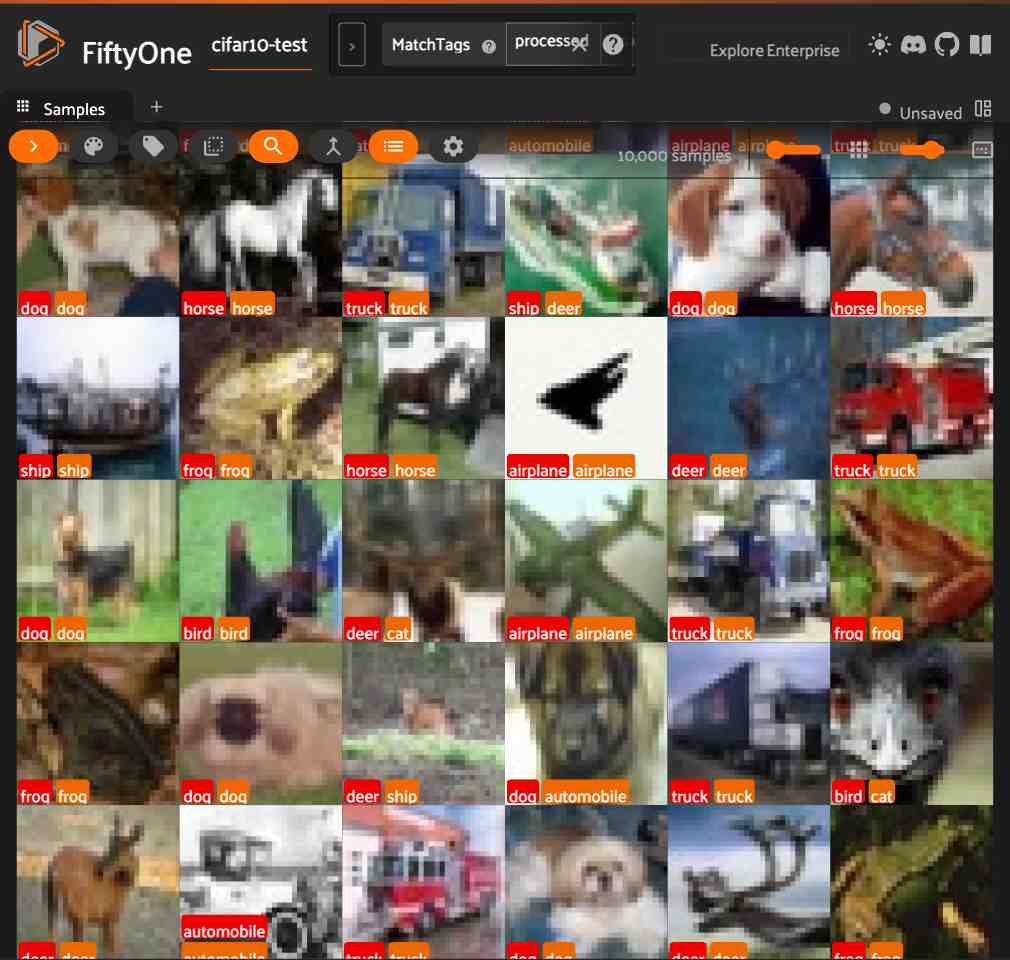

In [51]:
session = fo.launch_app(view=processed_view)

Computing hardness...
 100% |█████████████| 10000/10000 [6.8s elapsed, 0s remaining, 1.4K samples/s]        
Hardness computation complete



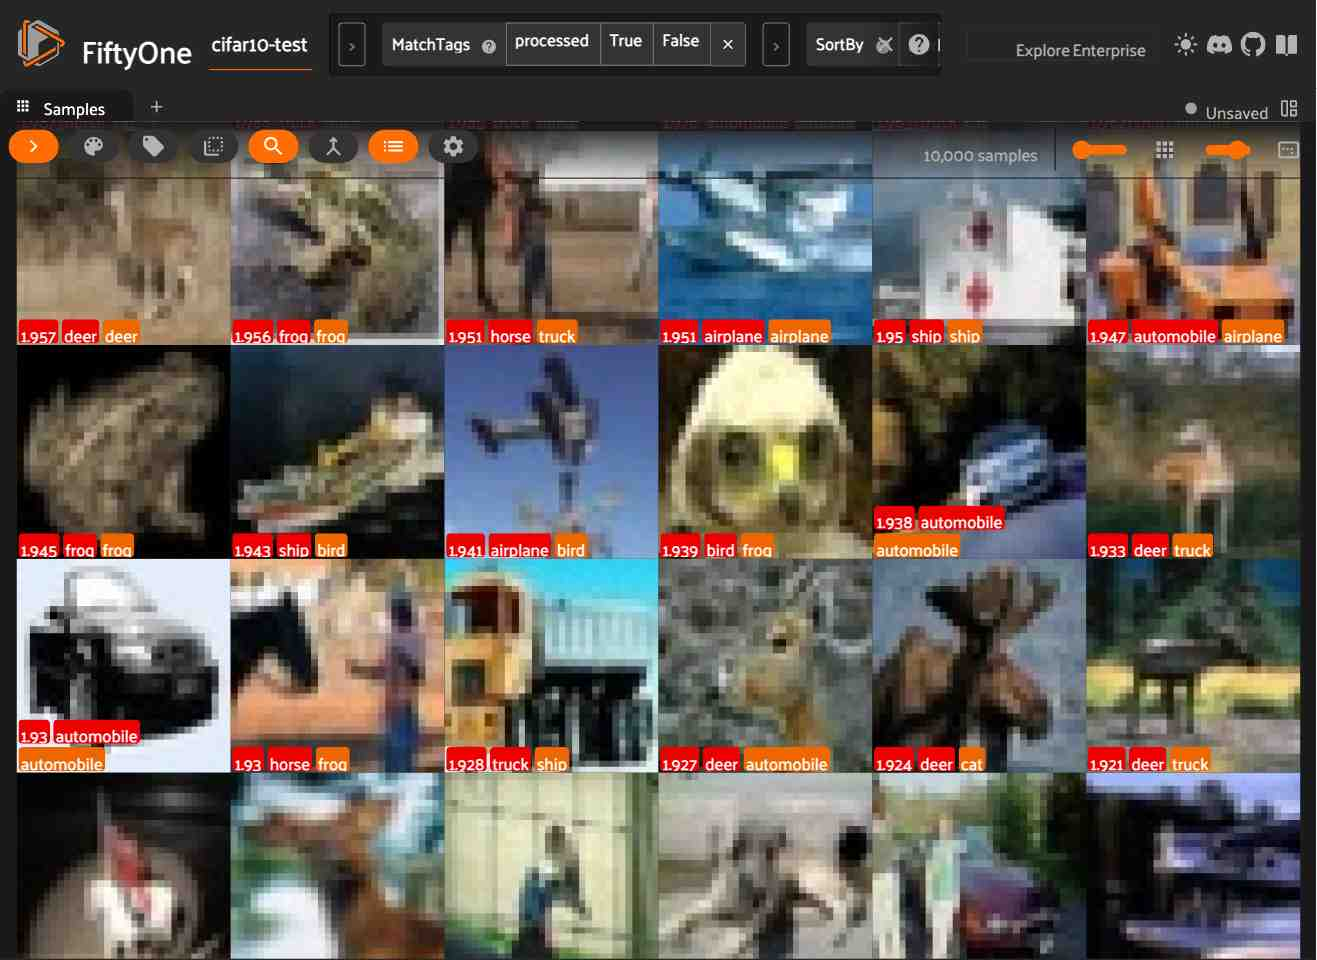

In [53]:
fob.compute_hardness(processed_view, label_field=model_name)
session.view = processed_view.sort_by("hardness", reverse=True)

In [54]:
correct_view = processed_view.match(F("ground_truth.label") == F(model_name+".label"))
incorrect_view = processed_view.match(F("ground_truth.label") != F(model_name+".label"))
incorrect_view.clone_sample_field("hardness", "hardness_incorrect")
correct_view.clone_sample_field("hardness", "hardness_correct")

for sample in processed_view:
    if sample.id in correct_view:
        sample["prediction"] = fo.Classification(label="correct")
    else:
        sample["prediction"] = fo.Classification(label="incorrect")
    sample.save()


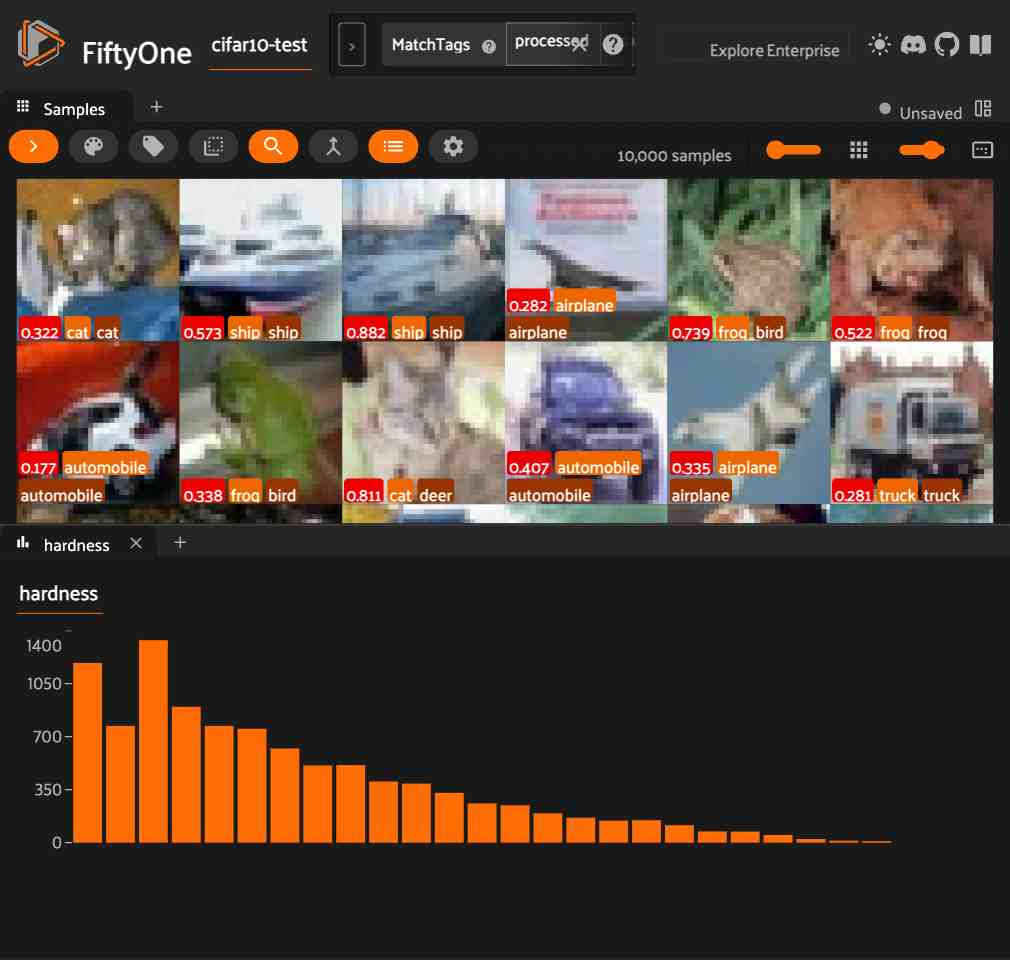

In [55]:
session.view = processed_view

In [56]:
cls_hardness = []

for label in processed_view.distinct("ground_truth.label"):
    label_view = processed_view.match(F("ground_truth.label")==label)
    avg_hardness = label_view.sum("hardness")/label_view.count()
    
    num_correct = correct_view.match(F("ground_truth.label")==label).count()
    accuracy = num_correct/label_view.count()
    
    cls_hardness.append([avg_hardness, label, accuracy])

print("Average classwise hardness\n")
for avg_hardness, label, _ in sorted(cls_hardness, reverse=True):
    print("%s: %f" % (label, avg_hardness))

Average classwise hardness

cat: 0.698599
dog: 0.626271
deer: 0.592497
frog: 0.584065
truck: 0.583196
bird: 0.579658
airplane: 0.578607
horse: 0.562866
ship: 0.547895
automobile: 0.530170


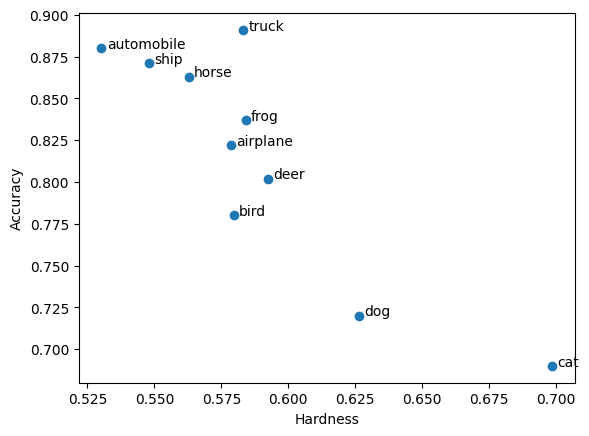

In [57]:
import matplotlib.pyplot as plt

avg_hardness = [i[0] for i in cls_hardness]
labels = [i[1] for i in cls_hardness]
acc = [i[2] for i in cls_hardness]

plt.scatter(avg_hardness, acc)
plt.xlabel("Hardness")
plt.ylabel("Accuracy")
for i, label in enumerate(labels):
    plt.annotate(label, (avg_hardness[i]+.002, acc[i]))
plt.show()

### representativeness

In [62]:
len(embeddings)

40670

In [61]:
fo.list_datasets()

['cifar10-test',
 'coco-2017-test',
 'demo0424',
 'kolp_dataset',
 'ls-annotation-example',
 'migration_test',
 'quickstart',
 'test_raw_imgs']

In [63]:
dataset =fo.load_dataset("coco-2017-test")
len(dataset)

40670

In [65]:
fob.compute_representativeness(
    dataset,
    embeddings=embeddings,
)

Computing representativeness...
Computing clusters for 40670 embeddings; this may take awhile...
Representativeness computation complete



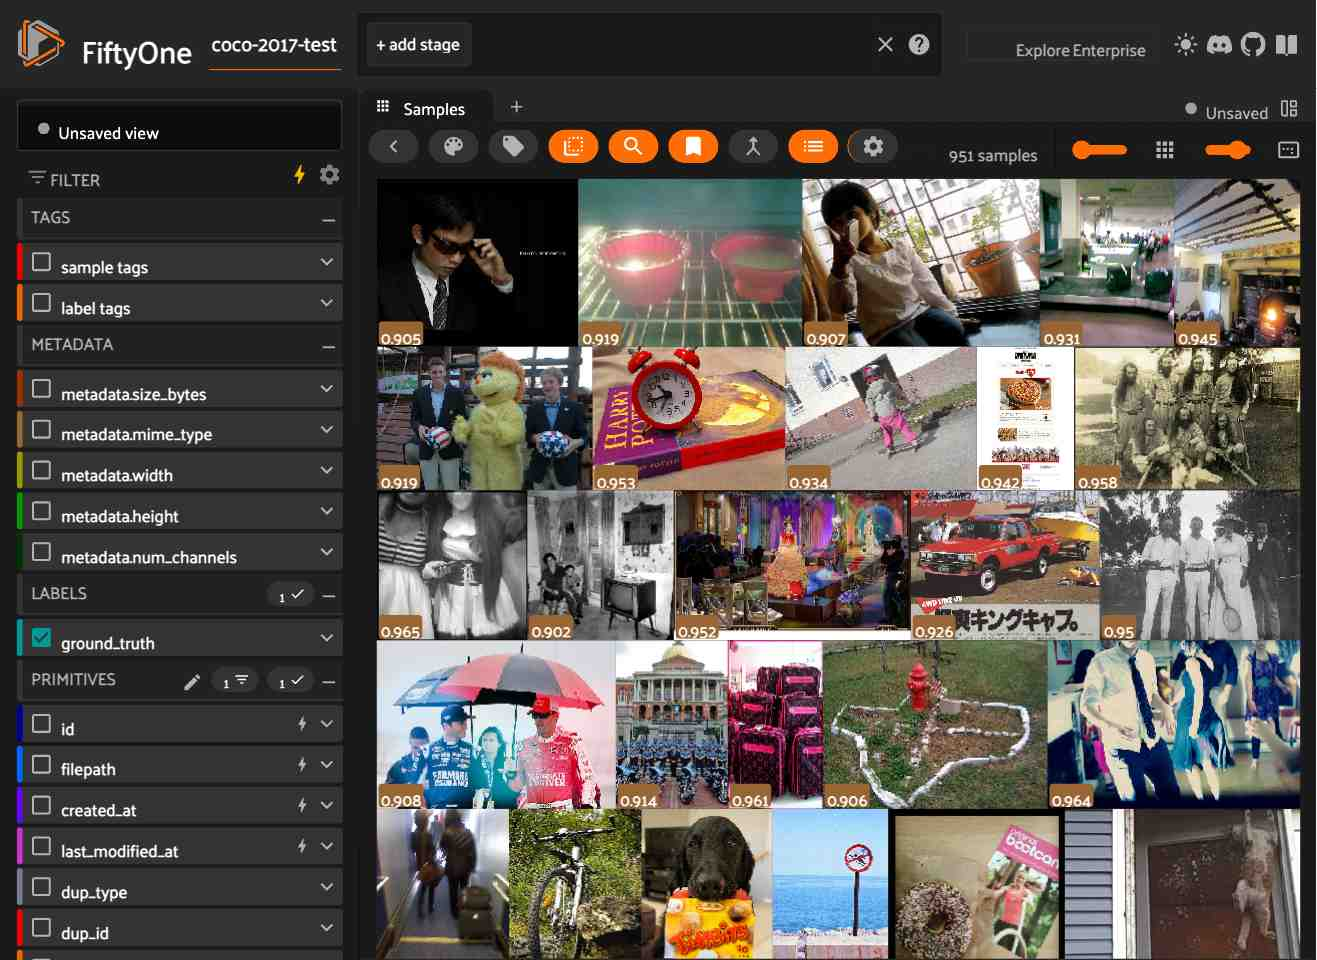

In [80]:
session = fo.launch_app(dataset)

In [81]:
fo.list_datasets()

['cifar10-test',
 'coco-2017-test',
 'demo0424',
 'kolp_dataset',
 'ls-annotation-example',
 'migration_test',
 'quickstart',
 'test_raw_imgs']

In [82]:
model = foz.load_zoo_model('faster-rcnn-resnet50-fpn-coco-torch')
dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="validation",
    dataset_name="evaluate-detections-tutorial",
)
dataset.persistent = True

 100% |██████|    1.2Gb/1.2Gb [3.7s elapsed, 0s remaining, 352.5Mb/s]      


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /Users/bhc/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:03<00:00, 46.0MB/s] 


 100% |██████|    1.9Gb/1.9Gb [7.0m elapsed, 0s remaining, 4.6Mb/s]       
Extracting annotations to '/Users/bhc/fiftyone/coco-2017/raw/instances_val2017.json'
 100% |██████|    6.1Gb/6.1Gb [1.0m elapsed, 0s remaining, 98.1Mb/s]       
Extracting images to '/Users/bhc/fiftyone/coco-2017/validation/data'
Writing annotations to '/Users/bhc/fiftyone/coco-2017/validation/labels.json'
Dataset info written to '/Users/bhc/fiftyone/coco-2017/info.json'
Loading 'coco-2017' split 'validation'
 100% |███████████████| 5000/5000 [10.3s elapsed, 0s remaining, 509.5 samples/s]      
Dataset 'evaluate-detections-tutorial' created


### add predictions

In [83]:
predictions_view = dataset.take(100, seed=51)
predictions_view.apply_model(model, label_field="faster_rcnn")
print(predictions_view)

 100% |█████████████████| 100/100 [1.3m elapsed, 0s remaining, 1.3 samples/s]      
Dataset:     evaluate-detections-tutorial
Media type:  image
Num samples: 100
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    faster_rcnn:      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
View stages:
    1. Take(size=100, seed=51)


### confidence thresholding

In [84]:
high_conf_view = predictions_view.filter_labels("faster_rcnn", F("confidence") > 0.75, only_matches=False)
print(high_conf_view)

Dataset:     evaluate-detections-tutorial
Media type:  image
Num samples: 100
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    faster_rcnn:      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
View stages:
    1. Take(size=100, seed=51)
    2. FilterLabels(field='faster_rcnn', filter={'$gt': ['$$this.confidence', 0.75]}, only_matches=False, trajectories=False)



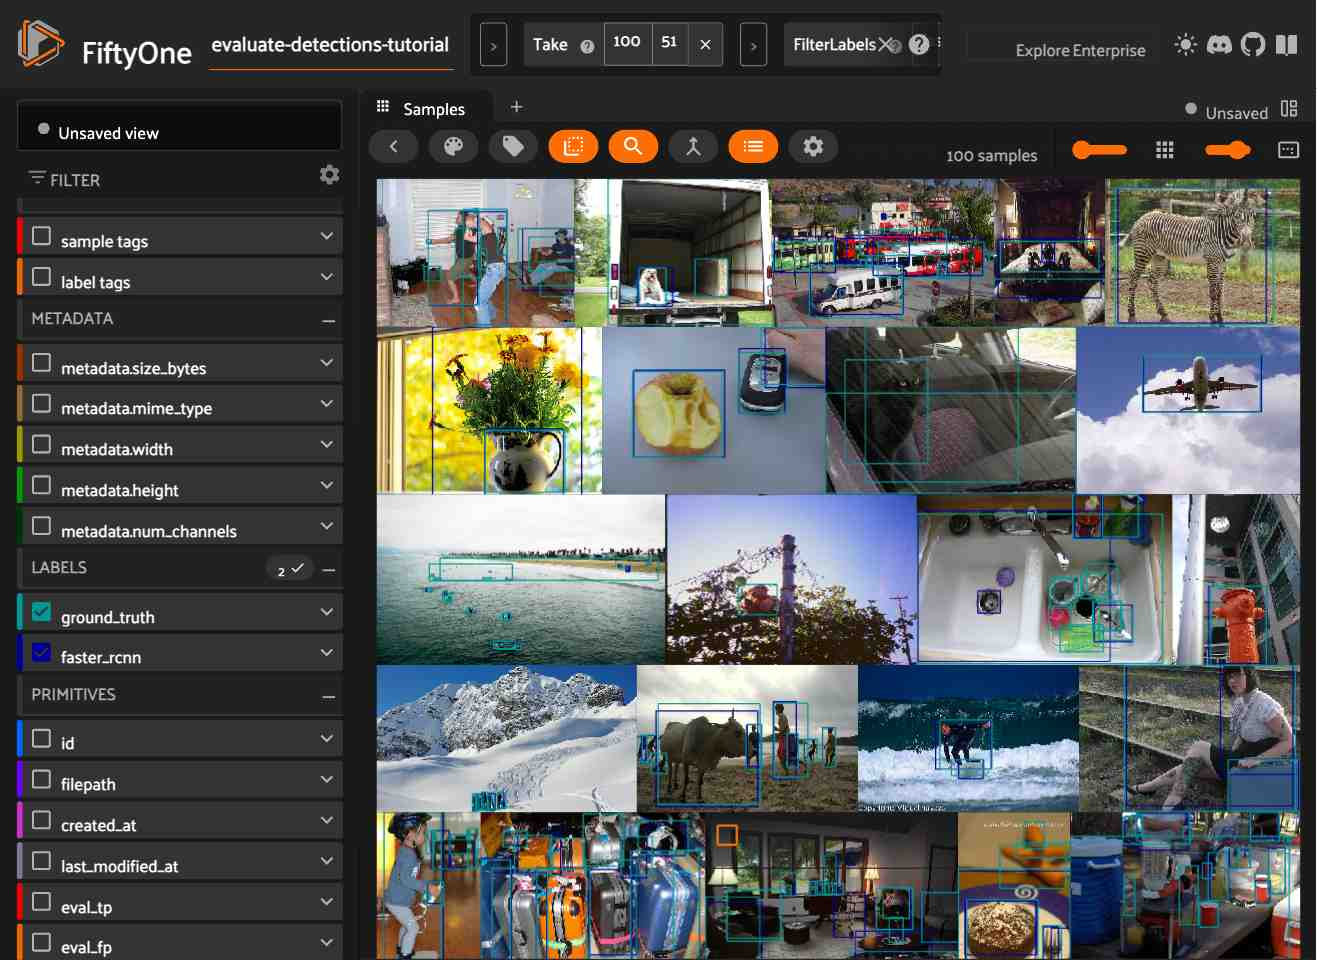

In [93]:
session = fo.launch_app(high_conf_view)

In [94]:
session.freeze()

: 

### running evaluation

In [87]:
results = high_conf_view.evaluate_detections(
    "faster_rcnn",
    gt_field="ground_truth",
    eval_key="eval",
    compute_mAP=True,
)

Evaluating detections...
 100% |█████████████████| 100/100 [889.4ms elapsed, 0s remaining, 112.4 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 100/100 [567.9ms elapsed, 0s remaining, 176.1 samples/s]      


In [88]:
## evaluation 정보 저장
print(dataset.list_evaluations())
print(dataset.get_evaluation_info("eval"))

['eval']
{
    "key": "eval",
    "version": "1.4.1",
    "timestamp": "2025-06-13T05:20:39.974000",
    "config": {
        "cls": "fiftyone.utils.eval.coco.COCOEvaluationConfig",
        "type": "detection",
        "method": "coco",
        "pred_field": "faster_rcnn",
        "gt_field": "ground_truth",
        "iou": 0.5,
        "classwise": true,
        "custom_metrics": null,
        "iscrowd": "iscrowd",
        "use_masks": false,
        "use_boxes": false,
        "tolerance": null,
        "compute_mAP": true,
        "iou_threshs": [
            0.5,
            0.55,
            0.6,
            0.65,
            0.7,
            0.75,
            0.8,
            0.85,
            0.9,
            0.95
        ],
        "max_preds": 100,
        "error_level": 1
    }
}


In [89]:
counts = dataset.count_values("ground_truth.detections.label")
classes_top10 = sorted(counts, key=counts.get, reverse=True)[:10]
results.print_report(classes=classes_top10)

               precision    recall  f1-score   support

       person       0.79      0.71      0.75       200
          car       0.38      1.00      0.56         5
        chair       0.69      0.35      0.46        52
         book       1.00      0.62      0.77        37
       bottle       0.67      0.57      0.62        21
          cup       0.68      0.36      0.47        42
 dining table       0.60      0.38      0.46        32
traffic light       0.00      0.00      0.00         3
         bowl       0.70      0.33      0.45        21
      handbag       0.67      0.29      0.40        14

    micro avg       0.74      0.56      0.64       427
    macro avg       0.62      0.46      0.49       427
 weighted avg       0.75      0.56      0.63       427



In [90]:
print(results.mAP())

0.33627348169478777


In [91]:
%matplotlib inline

plot = results.plot_pr_curves(classes=["person", "car"])
plot.show()

FigureWidget({
    'data': [{'customdata': array([0.99987364, 0.99981241, 0.99972826, 0.99930462, 0.99903469, 0.89948943,
                                   0.89941443, 0.89928656, 0.89909443, 0.89883709, 0.8986947 , 0.89850962,
                                   0.89830766, 0.89776098, 0.89739318, 0.89621125, 0.89522492, 0.89440272,
                                   0.88680115, 0.7969754 , 0.79687452, 0.79648847, 0.79611381, 0.79595584,
                                   0.79497226, 0.79392034, 0.79336013, 0.79263581, 0.79159089, 0.79063514,
                                   0.78857272, 0.78754278, 0.78579215, 0.78296109, 0.78042612, 0.77596467,
                                   0.76284989, 0.6847    , 0.6836503 , 0.68211486, 0.68114071, 0.68005065,
                                   0.67763135, 0.67359098, 0.67117147, 0.67074299, 0.66544281, 0.65573229,
                                   0.57527754, 0.57206642, 0.56826   , 0.56571112, 0.56168551, 0.55347788,
                      

In [92]:
sample = high_conf_view.first()
print(sample.faster_rcnn.detections[0])

<Detection: {
    'id': '684bb3929e8cc54221695119',
    'attributes': {},
    'tags': [],
    'label': 'person',
    'bounding_box': [
        0.2594649658203125,
        0.21519525146484375,
        0.2492353515625,
        0.6340693359375,
    ],
    'mask': None,
    'mask_path': None,
    'confidence': 0.9992185831069946,
    'index': None,
    'eval_iou': 0.9657918058774212,
    'eval_id': '684bb1ab9e8cc542216932bd',
    'eval': 'tp',
}>


## gradCAM with FiftyOne

In [1]:
import numpy as np
import torch

from pytorch_grad_cam import GradCAM, \
    ScoreCAM, \
    GradCAMPlusPlus, \
    AblationCAM, \
    XGradCAM, \
    EigenCAM, \
    EigenGradCAM, \
    LayerCAM, \
    FullGrad

from pytorch_grad_cam.ablation_layer import AblationLayerVit

In [2]:
import fiftyone as fo
import fiftyone.zoo as foz

dataset = foz.load_zoo_dataset("quickstart")
rand_test = dataset.take(20, seed=51)

fo_model = foz.load_zoo_model("deeplabv3-resnet50-coco-torch")

Dataset already downloaded
Loading existing dataset 'quickstart'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


In [3]:
rand_test.compute_metadata()
transforms = fo_model.transforms
transforms

Compose(
    Resize(size=520, interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [4]:
rand_test.apply_model(fo_model, label_field="resnet50_seg")

 100% |███████████████████| 20/20 [15.4s elapsed, 0s remaining, 1.3 samples/s]      


In [5]:
classes = fo_model.classes
classes_dict = {value: index for index, value in enumerate(classes)}

In [6]:
from PIL import Image
class ModelWrapper(torch.nn.Module):
    def __init__(self, model): 
        super(ModelWrapper, self).__init__()
        self.model = model
        
    def forward(self, x):
        return self.model(x)["out"]


model = ModelWrapper(fo_model._model)

In [7]:
class SemanticSegmentationTarget:
    def __init__(self, category, mask):
        self.category = category
        self.mask = torch.from_numpy(mask)
        if torch.backends.mps.is_available():
            self.mask = self.mask.to('mps')
        
    def __call__(self, model_output):
        return (model_output[self.category, :, : ] * self.mask).sum()

In [8]:
target_layers = [[model.model.backbone.layer4]]

In [9]:
methods = \
        {"gradcam": GradCAM,
         "scorecam": ScoreCAM,
         "gradcam++": GradCAMPlusPlus,
         "ablationcam": AblationCAM,
         "xgradcam": XGradCAM,
         "eigencam": EigenCAM,
         "eigengradcam": EigenGradCAM,
         "layercam": LayerCAM,}

In [10]:
from skimage.transform import resize
from tqdm.notebook import tqdm  # Jupyter notebook용 tqdm

# Check if MPS is available
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)

for index, target_layer in enumerate(target_layers):
    cam = methods["gradcam"](model=model,
                    target_layers=target_layers[0],)
    
    for sample in tqdm(rand_test, desc=f'Processing layer {index+1}/{len(target_layers)}'):
        #Load the Image and Preprocess
        image_path = sample.filepath
        rgb_img = Image.open(image_path)
        input_tensor = transforms(rgb_img).unsqueeze(0).to(device)

        #Generate mask
        output = model(input_tensor)

        #Create the target
        normalized_masks = torch.nn.functional.softmax(output, dim=1).cpu()
        person_mask = normalized_masks[0, :, :, :].argmax(axis=0).detach().cpu().numpy()
        person_category = classes_dict["person"]
        person_mask_float = np.float32(person_mask == person_category)

        targets = [SemanticSegmentationTarget(person_category, person_mask_float)]

        #Perform GradCam
        grayscale_cam = cam(input_tensor=input_tensor,
                            targets=targets,)

        # Here grayscale_cam has only one image in the batch
        grayscale_cam = grayscale_cam[0, :]

        #Save to sample
        sample[f"person_grad_layer_{index+1}"] = fo.Heatmap(map=grayscale_cam)
        sample.save()

Processing layer 1/1:   0%|          | 0/20 [00:00<?, ?it/s]


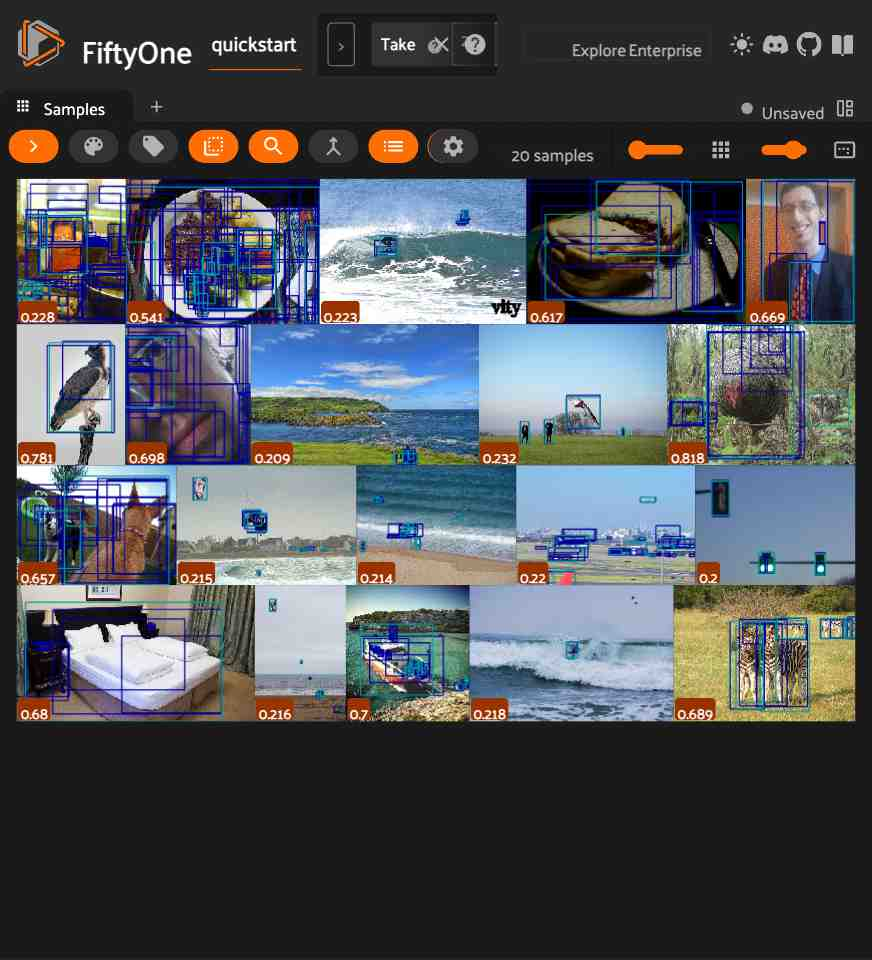

In [12]:
session = fo.launch_app(rand_test)